In [10]:
import pandas as pd
import os
import networkx as nx
from yfiles_jupyter_graphs import GraphWidget

# DATA LOADING

In [ ]:
df_adv = pd.read_csv(os.path.join(os.path.dirname(os.getcwd()), "NLP", "results", "docs_topic_weights.csv"))
df_obs = pd.read_csv(os.path.join(os.path.dirname(os.path.dirname(os.getcwd())), "data", "processed", "data_obs.csv"))
df_obs.drop(df_obs.columns[0], axis=1, inplace=True)
df_obs["condition"] = "OBS"
df_adv["condition"] = "ADV"
df = pd.concat([df_obs, df_adv])

# ANALYSIS

This was made using Copilot

In [ ]:
def build_graph(data):
    G = nx.DiGraph()
    for _, row in data.iterrows():
        G.add_node(row['ID'], generation=row['gen'], score=row['score_corrected'], condition=row['condition'])
        if pd.notna(row['parent_ID']):
            G.add_edge(row['parent_ID'], row['ID'])
    return G

def lineage_size(G, root):
    return len(nx.descendants(G, root))

def analyze_lineages(data, G):
    roots = data['ID'].tolist()
    root_conditions = data.set_index('ID')['condition'].to_dict()
    results = []
    for root in roots:
        results.append({
            'root_ID': root,
            'condition': root_conditions[root],
            'lineage_size': lineage_size(G, root)
        })
    return pd.DataFrame(results)

def run_lineage_analysis(data):
    G = build_graph(data)
    results = analyze_lineages(data, G)
    return results

results = run_lineage_analysis(df)
max_sizes_by_condition = results.groupby('condition')['lineage_size'].max()
print(max_sizes_by_condition)

condition
ADV    391
OBS    155
Name: lineage_size, dtype: int64


# VISUALISATION

### ADVICE CONDITION

In [12]:
def get_descendants(target_id, df):
    """ Recursively retrieve all descendants of a given target_id """
    descendants = set()
    children = df[df["parent_ID"] == target_id]["ID"]
    
    for child in children:
        descendants.add(child)
        descendants.update(get_descendants(child, df))  # Recursively find their descendants
    
    return descendants

target_id = "5da83385e8bf0200113c3c6e"  # Replace with the actual ID you want to track

descendant_ids = get_descendants(target_id, df_adv)

# Filter dataset to keep only descendants of the given ID
df_filtered = df_adv[df_adv["ID"].isin(descendant_ids) | (df_adv["ID"] == target_id)]
df_filtered.loc[df_filtered["assigned_topic"] > 5, "assigned_topic"] = -1

nodes = []
edges = []

for row in df_filtered.iterrows():
    ID = row[1]["ID"]
    pID = row[1]["parent_ID"]
    gen = row[1]["gen"]
    topic = row[1]["assigned_topic"]
    rank = row[1]["rank"]
    advice = row[1]["ADVICE"]
    
    nodes.append(
        {"id": ID, "properties": {"ID": ID, "gen": gen, "topic": topic, "advice": advice, "parent_ID": pID, "rank": rank}}
    )
    edges.append(
        {"start": pID, "end": ID}
    )


node_colors = {}

def custom_style_mapping(index, node):
    color_palette = ["#3B575D", "#5B5C5F", "#FF6B6B", "#22545C", "#C36967", "#1A535C"]
    shape_palette = [
        "triangle",
        "rectangle",
        "round-rectangle",
        "ellipse",
        "hexagon",
        "octagon"
    ]

    topic = node.get("properties", {}).get("topic", 0)  # Default to 0 if missing
    label = node.get("properties", {}).get("label", "")

    if topic == -1:
        color = "grey"
        shape = "diamond"  # Note: 'triangle_pointing_right' might not be supported; use 'triangle' or 'right-triangle'
    
    else:
        color = color_palette[topic]
        shape = shape_palette[topic]

    node_colors[node["id"]] = color

    # Return proper style dict
    return {
        "shape": shape,
        "color": color,
        "stroke": "black",  # Optional: for border color
        "label": label,
        "text": advice
    }

def custom_edge_color_mapping(index, edge):
    source_id = edge["start"]  # The starting node ID of this edge
    color = node_colors.get(source_id, "black")  # Default to black if not found
    return color

# Update GraphWidget
w = GraphWidget()
w.nodes = nodes
w.edges = edges
w.set_node_styles_mapping(custom_style_mapping)
w.set_edge_color_mapping(custom_edge_color_mapping)
w.directed = True
w.organic_layout()

display(w)

GraphWidget(layout=Layout(height='800px', width='100%'))

### OBSERVATION CONDITION

In [ ]:
def get_descendants(target_id, df):
    """ Recursively retrieve all descendants of a given target_id """
    descendants = set()
    children = df[df["parent_ID"] == target_id]["ID"]
    
    for child in children:
        descendants.add(child)
        descendants.update(get_descendants(child, df))  # Recursively find their descendants
    
    return descendants

#target_id = "66beecc36f5efc681981933f"  # Replace with the actual ID you want to track

#descendant_ids = get_descendants(target_id, df_obs)

# Filter dataset to keep only descendants of the given ID
#df_filtered = df_obs[df_obs["ID"].isin(descendant_ids) | (df_obs["ID"] == target_id)]

df_filtered = df_obs

nodes = []
edges = []

for row in df_filtered.iterrows():
    ID = row[1]["ID"]
    pID = row[1]["parent_ID"]
    gen = row[1]["gen"]
    rank = row[1]["rank"]
    
    nodes.append(
        {"id": ID, "properties": {"ID": ID, "gen": gen, "parent_ID": pID, "rank": rank}}
    )
    edges.append(
        {"start": pID, "end": ID}
    )


node_colors = {}

def custom_style_mapping(index, node):
    color = "green"
    shape = "diamond"  # Note: 'triangle_pointing_right' might not be supported; use 'triangle' or 'right-triangle'

    # Return proper style dict
    return {
        "shape": shape,
        "color": color,
        "stroke": "black",  # Optional: for border color
    }

def custom_edge_color_mapping(index, edge):
    source_id = edge["start"]  # The starting node ID of this edge
    color = node_colors.get(source_id, "black")  # Default to black if not found
    return color

# Update GraphWidget
w = GraphWidget()
w.nodes = nodes
w.edges = edges
w.set_node_styles_mapping(custom_style_mapping)
w.set_edge_color_mapping(custom_edge_color_mapping)
w.directed = True
w.organic_layout()

display(w)

GraphWidget(layout=Layout(height='800px', width='100%'))

# NOT IN THE PAPER


=== Summary of Lineage Metrics by Condition ===
           lineage_depth  lineage_size  branching_factor
condition                                               
ADV             0.902222           4.0          0.292520
OBS             0.971111           4.0          0.288181

=== Statistical Comparisons Between Conditions ===
                     mean_OBS  mean_ADV  t_test_p  u_test_p
lineage_depth        0.971111  0.902222  0.363765  0.903971
lineage_size         4.000000  4.000000  1.000000  0.874675
branching_factor     0.288181  0.292520  0.807250  0.874675
lineage_entropy      0.311741  0.281347  0.416971  0.720712
max_path_score       0.892395  1.307567  0.000060  0.000001
max_path_length      0.818889  0.775556  0.551855  0.418856
path_score_variance  0.156250  0.192571  0.044013  0.190790
score_smoothness     0.198021  0.265847  0.014016  0.176078

=== Plotting Survival Curves ===


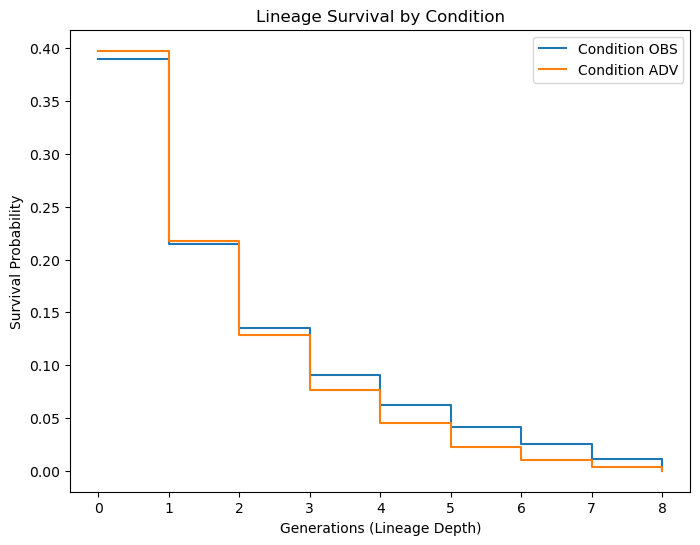

,root_ID,condition,lineage_depth,lineage_size,branching_factor,lineage_entropy,max_path_score,max_path_length,path_score_variance,score_smoothness
0,575865ba7b74a80006de2689,OBS,8,28,0.965517,2.798273,6.156756,7,0.204638,0.658025
1,575b2b408b705300078ae5e6,OBS,1,2,0.666667,0.000000,-0.047619,0,0.075846,-0.010820
2,57b76ef5017c2d000166f019,OBS,5,13,0.928571,2.160847,2.945117,4,0.144933,0.493496
3,57ff8c2d90de420001673aa0,OBS,1,1,0.500000,0.000000,0.245098,0,0.113947,0.058503
4,5848ad3bdb871400012da095,OBS,0,0,0.000000,0.000000,-0.614583,0,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...
1795,668ac13f677dc562a445d890,ADV,0,0,0.000000,0.000000,-0.170683,0,0.000000,0.000000
1796,668b922089b899b8acf2035d,ADV,0,0,0.000000,0.000000,-0.492157,0,0.000000,0.000000
1797,668bc36024945804c1276ebc,ADV,0,0,0.000000,0.000000,1.604418,0,0.000000,0.000000
1798,668bfc03a3529d7791c62b19,ADV,0,0,0.000000,0.000000,-0.049213,0,0.000000,0.000000


In [ ]:
from scipy.stats import entropy
import pandas as pd
import networkx as nx
import os
from lifelines import KaplanMeierFitter
from scipy.stats import ttest_ind, mannwhitneyu
import matplotlib.pyplot as plt
import numpy as np

df_adv = pd.read_csv(os.path.join(os.path.dirname(os.getcwd()), "NLP", "results", "docs_topic_weights.csv"))
df_obs = pd.read_csv(os.path.join(os.path.dirname(os.path.dirname(os.getcwd())), "data", "processed", "data_obs.csv"))
df_obs.drop(df_obs.columns[0], axis=1, inplace=True)
df_obs["condition"] = "OBS"
df_adv["condition"] = "ADV"
df = pd.concat([df_obs, df_adv])


# ---------------------------
# Compute Lineage Metrics
# ---------------------------

def lineage_depth(G, root):
    lengths = nx.single_source_shortest_path_length(G, root)
    return max(lengths.values())

def lineage_size(G, root):
    return len(nx.descendants(G, root))

def branching_factor(G, root):
    lineage_nodes = nx.descendants(G, root) | {root}
    return sum(len(list(G.successors(n))) for n in lineage_nodes) / len(lineage_nodes)



def compute_lineage_entropy(G, roots):
    entropies = []
    for root in roots:
        descendants = nx.descendants(G, root)
        children_counts = [len(nx.descendants(G, node)) for node in descendants]
        children_counts = [c for c in children_counts if c > 0]  # Remove zeros to avoid log(0)
        if len(children_counts) > 1:
            p = pd.Series(children_counts) / sum(children_counts)
            ent = entropy(p, base=2)
        else:
            ent = 0
        entropies.append({'root_ID': root, 'lineage_entropy': ent})
    return pd.DataFrame(entropies)

def best_lineage_path_score(G, root):
    paths = nx.single_source_shortest_path(G, root)
    max_score = -float('inf')
    best_path = []
    for path in paths.values():
        scores = [G.nodes[node]['score'] for node in path]
        total_score = sum(scores)
        if total_score > max_score:
            max_score = total_score
            best_path = path
    return max_score, len(best_path) - 1  # path length in generations


def path_score_variability(G, root):
    paths = nx.single_source_shortest_path(G, root)
    path_variances = []
    for path in paths.values():
        if len(path) > 1:
            scores = [G.nodes[n]['score'] for n in path]
            path_variances.append(pd.Series(scores).var())
    return np.mean(path_variances) if path_variances else 0

def graph_score_smoothness(G, root):
    nodes = list(nx.descendants(G, root)) + [root]
    subgraph = G.subgraph(nodes)
    A = nx.adjacency_matrix(subgraph).toarray()
    D = np.diag(np.sum(A, axis=1))
    L = D - A
    scores = np.array([G.nodes[n]['score'] for n in subgraph.nodes()])
    smoothness = scores.T @ L @ scores  # Laplacian quadratic form
    return smoothness / len(scores)  # normalize by size

# ---------------------------
# Aggregate Lineage Metrics
# ---------------------------

def analyze_lineages(data, G):
    roots = data['ID'].tolist()
    root_conditions = data.set_index('ID')['condition'].to_dict()
    entropies_df = compute_lineage_entropy(G, roots).set_index('root_ID')
    
    results = []
    for root in roots:
        max_score, path_length = best_lineage_path_score(G, root)
        score_var = path_score_variability(G, root)
        smoothness = graph_score_smoothness(G, root)
        results.append({
            'root_ID': root,
            'condition': root_conditions[root],
            'lineage_depth': lineage_depth(G, root),
            'lineage_size': lineage_size(G, root),
            'branching_factor': branching_factor(G, root),
            'lineage_entropy': entropies_df.loc[root, 'lineage_entropy'],
            'max_path_score': max_score,
            'max_path_length': path_length,
            'path_score_variance': score_var,
            'score_smoothness': smoothness
        })
    
    return pd.DataFrame(results)

def plot_survival(results):
    kmf = KaplanMeierFitter()

    plt.figure(figsize=(8, 6))
    for condition in results['condition'].unique():
        lifetimes = results.loc[results['condition'] == condition, 'lineage_depth']
        kmf.fit(lifetimes, event_observed=[1] * len(lifetimes), label=f"Condition {condition}")
        kmf.plot_survival_function(ci_show=False)

    plt.title("Lineage Survival by Condition")
    plt.xlabel("Generations (Lineage Depth)")
    plt.ylabel("Survival Probability")
    plt.legend()
    plt.show()

# ---------------------------
# Statistical Tests
# ---------------------------

def compare_conditions(results):
    metrics = ['lineage_depth', 'lineage_size', 'branching_factor', 'lineage_entropy', 'max_path_score', 'max_path_length', 'path_score_variance', 'score_smoothness']
    conditions = results['condition'].unique()
    if len(conditions) != 2:
        raise ValueError("Currently set up for exactly two conditions.")
    
    cond1, cond2 = conditions
    summary = {}
    for metric in metrics:
        x = results.loc[results['condition'] == cond1, metric]
        y = results.loc[results['condition'] == cond2, metric]
        
        t_stat, t_pval = ttest_ind(x, y, equal_var=False)
        u_stat, u_pval = mannwhitneyu(x, y, alternative='two-sided')
        
        summary[metric] = {
            'mean_{}'.format(cond1): x.mean(),
            'mean_{}'.format(cond2): y.mean(),
            't_test_p': t_pval,
            'u_test_p': u_pval
        }
    return pd.DataFrame(summary).T

# ---------------------------
# Master Function to Run All
# ---------------------------

def run_lineage_analysis(data):
    # Filter out the last generation (generation 10)
    data_filtered = data[data['gen'] < 10]
    G = build_graph(data_filtered)
    results = analyze_lineages(data_filtered, G)
    print("\n=== Summary of Lineage Metrics by Condition ===")
    print(results.groupby('condition')[['lineage_depth', 'lineage_size', 'branching_factor']].mean())
    
    print("\n=== Statistical Comparisons Between Conditions ===")
    stats = compare_conditions(results)
    print(stats)
    
    print("\n=== Plotting Survival Curves ===")
    plot_survival(results)
    
    return results, stats

# ---------------------------
# Example Usage
# ---------------------------

results, stats = run_lineage_analysis(data)

# You can export the results if needed
# results.to_csv("lineage_metrics.csv", index=False)
# stats.to_csv("lineage_stats.csv", index=True)

results